# Mathematical Tools

### Exercise 1
Verify that the flow map $y(t) = \phi(t)y_{0}$, where $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, does solve $\dot{y} = By$. What hypotheses must the eigenvectors $v_i$ satisfy for the matrix $X^{e}(t)$ to be invertible? For what sorts of matrices B do these hypotheses always hold?

#### Answer

##### First part:

given 

$\dot{y} = By$

and the solution

$\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, does solve $\dot{y} = By$

By definition, $X^{e}(t)$ is a fundamental solution matrix whose columns are individual solutions to the linear system. Therefore,

$\dot{X}^{e}(t) = BX^{e}(t)$

If you differentiate $\phi(t)$, remembering that $\phi(0) = I$, which is a constant matrix, you get:

$\dot{\phi}(t) = B\phi(t)$

Differentiating $y(t)$ yields, where $y_0$ is a constant:

$\dot{y}(t) = \dot{\phi}(t)y_{0} = B\phi(t)y_{0}$

Taking $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, multiply both sides by $y_0$:

$\phi(t)y_{0} = X^{e}(t)[X^{e}(0)]^{-1}y_(0)$

Matrix multiplication is associative:

$\phi(t)y_{0} = (X^{e}(t)) * ([X^{e}(0)]^{-1})(y_{0})$

$([X^{e}(0)]^{-1})(y_(0))$ is a constant. Let it be c.

$\phi(t)(y_0) = X^{e}(t)c$

By definition, any general solution to the linear system $\dot{y}(t) = By$ is a linear combination of the fundamental matrix, which is exactly written as $\phi(t)(y_0) = X^{e}(t)c$ where c is any constant.So,

$\phi(t)y_{0} = y(t)$

So,

$\dot{y}(t) = \dot{\phi}(t)y_{0} = B\phi(t)y_{0} = By(t)$

Which is what we wanted to verify.

##### Second approach to this
This method relies more on algebra and is a little shorter. I was reviewing these notes and did this out, makes no sense not to include it. Same question, given $y(t) = \phi(t)y_{0}$ and the solution $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, does solve $\dot{y} = By$.

$$\dot{y}(t) = \dot{\phi}(t)y_{0}$$ and $$\dot{\phi}(t) = \dot{X}^{e}(t)[X^{e}(0)]^{-1}$$
Messing with these yields: $$\dot{\phi}y_{0} = B\phi(t)y_{0}$$
Through substitution: $$\dot{X}^{e}(t)[X^{e}(0)]^{-1}y_{0} = BX^{e}(t)[X^{e}(0)]^{-1}y_{0}$$
Cancelling (technically multiplying by inverse matrix): $$\dot{X}^{e}(t) = BX^{e}(t)$$
By definition, $X^{e}(t)$ is a fundamental solution matrix whose columns are individual solutions to the linear system. So, $$\dot{X}^{e}(t) = BX^{e}(t)$$ 

##### Third (and final) approach
I still didn't like either of those. This one is more ground-up and cleaner. Same question, given $y(t) = \phi(t)y_{0}$ and the solution $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$, does solve $\dot{y} = By$.

$X^{e}(t)$ is the fundamental solution matrix whose columns are individual solutions to the linear system. This means that: $$\dot{X}^{e}(t) = BX^{e}(t)$$ Multiply both sides by $[X^{e}(0)]^{-1}$ to yield: $$\dot{X}^{e}(t)[X^{e}(0)]^{-1} = BX^{e}(t)[X^{e}(0)]^{-1}$$
Differentiating $\phi(t) = X^{e}(t)[X^{e}(0)]^{-1}$ gives: $$\dot{\phi}(t) = \dot{X}^{e}(t)[X^{e}(0)]^{-1}$$ So, we can sub both $\phi$ and it's derivative into our original equation to give: $$\dot{\phi}(t) = B\phi(t)$$ Multiply both sides by $y_{0}$ to give $$\dot{\phi}(t)y_{0} = B\phi(t)y_{0}$$ As we know $y(t) = \phi(t)y_{0}$, it's derivative is $\dot{y}(t) = \dot{\phi}(t)y_{0}$ Subbing these in yields: $$\dot{y}(t) = By(t)$$ which is equivalent to $$\dot{y} = By$$
##### Second part:

For the matrix to be invertible, its determinant must be non-zero. This is the same as n linearly independent eigenvectors.

##### Third part:

These hypotheses will hold for diagonalisable matrices:

Matrices with distinct eigenvalues

Matrices that are symmetric, i.e. $B=B^t$, due to the  real Spectral Theorem. Spectral Theorem guarantees that all eigenvalues are real, and it always possesses a full set of n mutually orthogonal eigenvectors. So, you can have repeated eigenvalues and still have linearly independent eigenvectors.

### Example 1

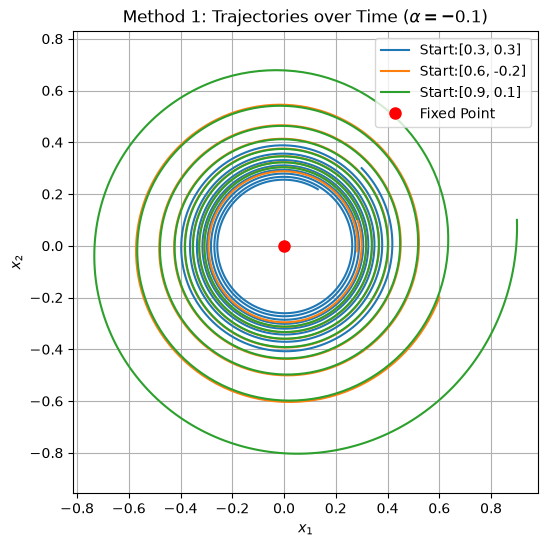

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#The function
def degenerate_system(t, z, alpha):
    x1, x2 = z #have to package them together for solve_ivp
    r_sq = x1**2 + x2**2  # This is (x1^2 + x2^2)
    
    dx1_dt = x2 + alpha * r_sq * x1  # x2 + alpha*(x1^2 + x2^2)*x1
    dx2_dt = -x1 + alpha * r_sq * x2 # -x1 + alpha*(x1^2 + x2^2)*x2
    return [dx1_dt, dx2_dt]
    
# Setup
t_span=(0,50)
t_eval = np.linspace(0, 50, 2000)
alpha_val = -0.1 #checking negative alpha first, should be stable
initial_conditions = [[0.3,0.3], [0.6,-0.2], [0.9,0.1]]

#The plot
plt.figure(figsize=(6,6))

for ic in initial_conditions:
    sol = solve_ivp(degenerate_system, t_span, ic, args=(alpha_val,), t_eval = t_eval)
    plt.plot(sol.y[0], sol.y[1], label = f"Start:{ic}")

plt.plot(0,0, 'ro', markersize = 8, label= "Fixed Point")
plt.title(r"Method 1: Trajectories over Time ($\alpha = -0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

#So this runs solve_ivp 2000 times at equal intervals for each set of initial conditions.

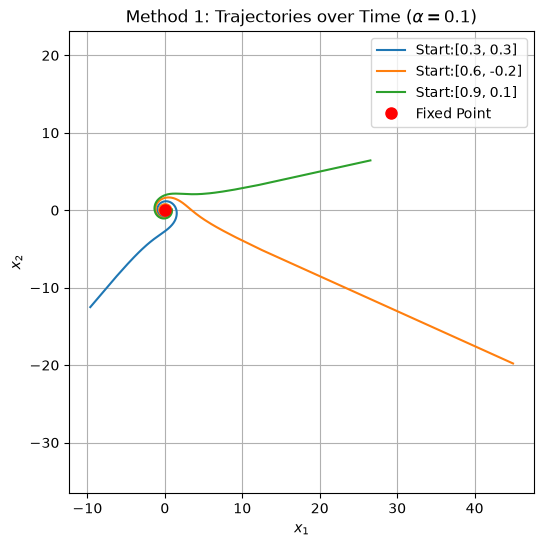

In [27]:
# Setup
t_span=(0,50)
t_eval = np.linspace(0, 50, 2000)
alpha_val = 0.1
initial_conditions = [[0.3,0.3], [0.6,-0.2], [0.9,0.1]]

#The plot
plt.figure(figsize=(6,6))

for ic in initial_conditions:
    sol = solve_ivp(degenerate_system, t_span, ic, args=(alpha_val,), t_eval = t_eval)
    plt.plot(sol.y[0], sol.y[1], label = f"Start:{ic}")

plt.plot(0,0, 'ro', markersize = 8, label= "Fixed Point")
plt.title(r"Method 1: Trajectories over Time ($\alpha = 0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

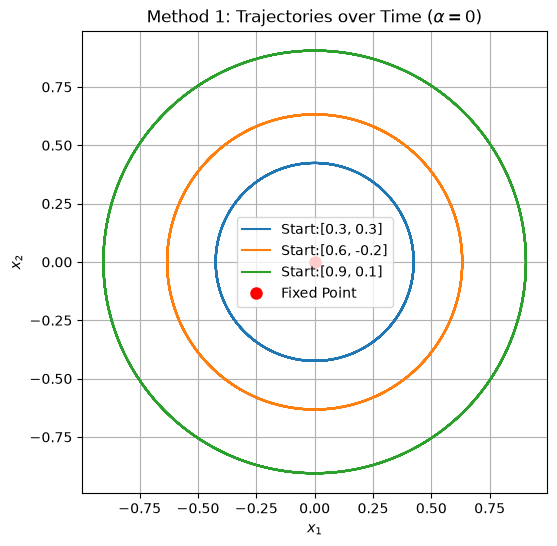

In [28]:
# Setup
t_span=(0,50)
t_eval = np.linspace(0, 50, 2000)
alpha_val = 0
initial_conditions = [[0.3,0.3], [0.6,-0.2], [0.9,0.1]]

#The plot
plt.figure(figsize=(6,6))

for ic in initial_conditions:
    sol = solve_ivp(degenerate_system, t_span, ic, args=(alpha_val,), t_eval = t_eval)
    plt.plot(sol.y[0], sol.y[1], label = f"Start:{ic}")

plt.plot(0,0, 'ro', markersize = 8, label= "Fixed Point")
plt.title(r"Method 1: Trajectories over Time ($\alpha = 0$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

So, we can see how different alphas affect the trajectory. However, this only works for specific inputs, and is inefficent. Let's see if I can get a phase plane.

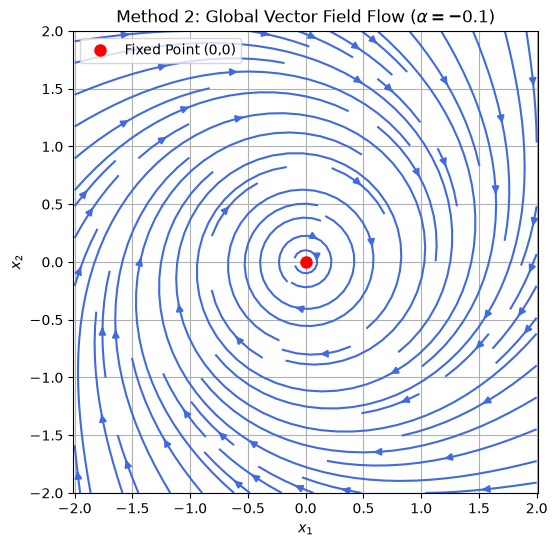

In [29]:
#Pick arbitrary values for coordinate grid
x1_vals = np.linspace(-2,2,20)
x2_vals = np.linspace(-2,2,20)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

alpha_val=-0.1
DX1, DX2 = degenerate_system(0, [X1, X2], alpha_val)

plt.figure(figsize=(6, 6))
plt.streamplot(X1, X2, DX1, DX2, color='royalblue', density=1)
plt.plot(0, 0, 'ro', markersize=8, label="Fixed Point (0,0)")

plt.title(r"Method 2: Global Vector Field Flow ($\alpha = -0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

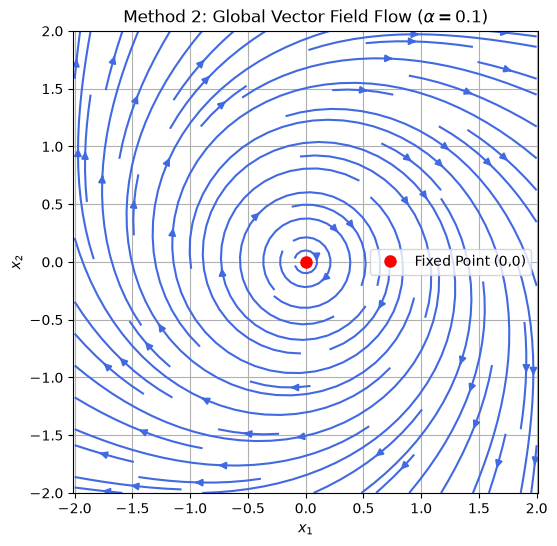

In [30]:
alpha_val=0.1
DX1, DX2 = degenerate_system(0, [X1, X2], alpha_val)

plt.figure(figsize=(6, 6))
plt.streamplot(X1, X2, DX1, DX2, color='royalblue', density=1)
plt.plot(0, 0, 'ro', markersize=8, label="Fixed Point (0,0)")

plt.title(r"Method 2: Global Vector Field Flow ($\alpha = 0.1$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

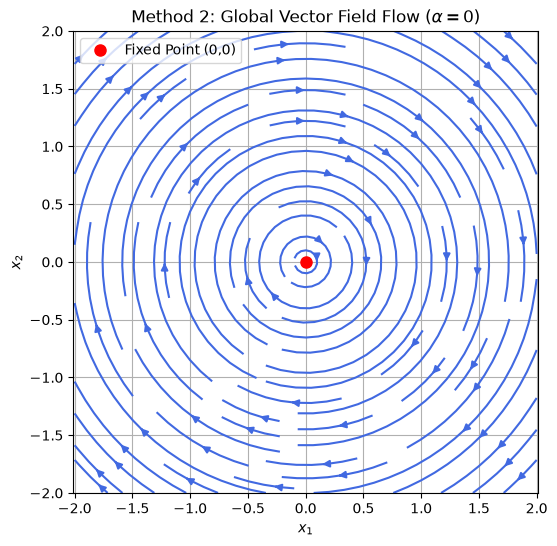

In [31]:
alpha_val=0
DX1, DX2 = degenerate_system(0, [X1, X2], alpha_val)

plt.figure(figsize=(6, 6))
plt.streamplot(X1, X2, DX1, DX2, color='royalblue', density=1)
plt.plot(0, 0, 'ro', markersize=8, label="Fixed Point (0,0)")

plt.title(r"Method 2: Global Vector Field Flow ($\alpha = 0$)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

#### Takeaways
If I were to linearise that system, it would tell me it's a center. The Hartman-Grobman theorem, which states that the behaviour of a dynamical system near a hyperbolic equlibrium point is qualitatively the same as the behaviour of its linearization near that point, does not apply, as we can see. It depends on the value of alpha, which gets discarded in the linearisation. 

When the taylor series is 0, alarm bells. What is usually discarded becomes the very thing driving the system. 

When encountering a new system:
- Find the fixed points. Set the function = 0 and solve.
- Linearise. Calculate the Jacobian at the fixed point.
- Check hyperbolicity. If eigenvalues of Jacobian don't equal 0, then you can trust your linearisation. The Hartman-Grobman theorem applies. If they equal 0, you cannot trust your linearisation.
- If degenerate, switch to polar coordinates, construct a Lyapunov function (next), or run a numerical simulation. 


### Example 2
Let's revisit the system from example 1.

Let $V = (x^{2}+y^{2})/2$

$\dot{V} = x\dot{x}+y\dot{y}
=x(y+\alpha(x^{2}+y^{2})x)+y(-x+\alpha(x^{2}+y^{2})y)
=\alpha(x^{2}+y^{2})^{2}$

So we can see how $V(x)$ is always positive, and it's derivative is dependent on $\alpha$. If $\alpha<0, \dot{V}<0, \forall (x,y) \neq (0,0)$, implying asymptotic stability, while for $\alpha > 0$, $\dot{V} > 0$ $\forall (x,y) \neq (0,0)$, implying instability.

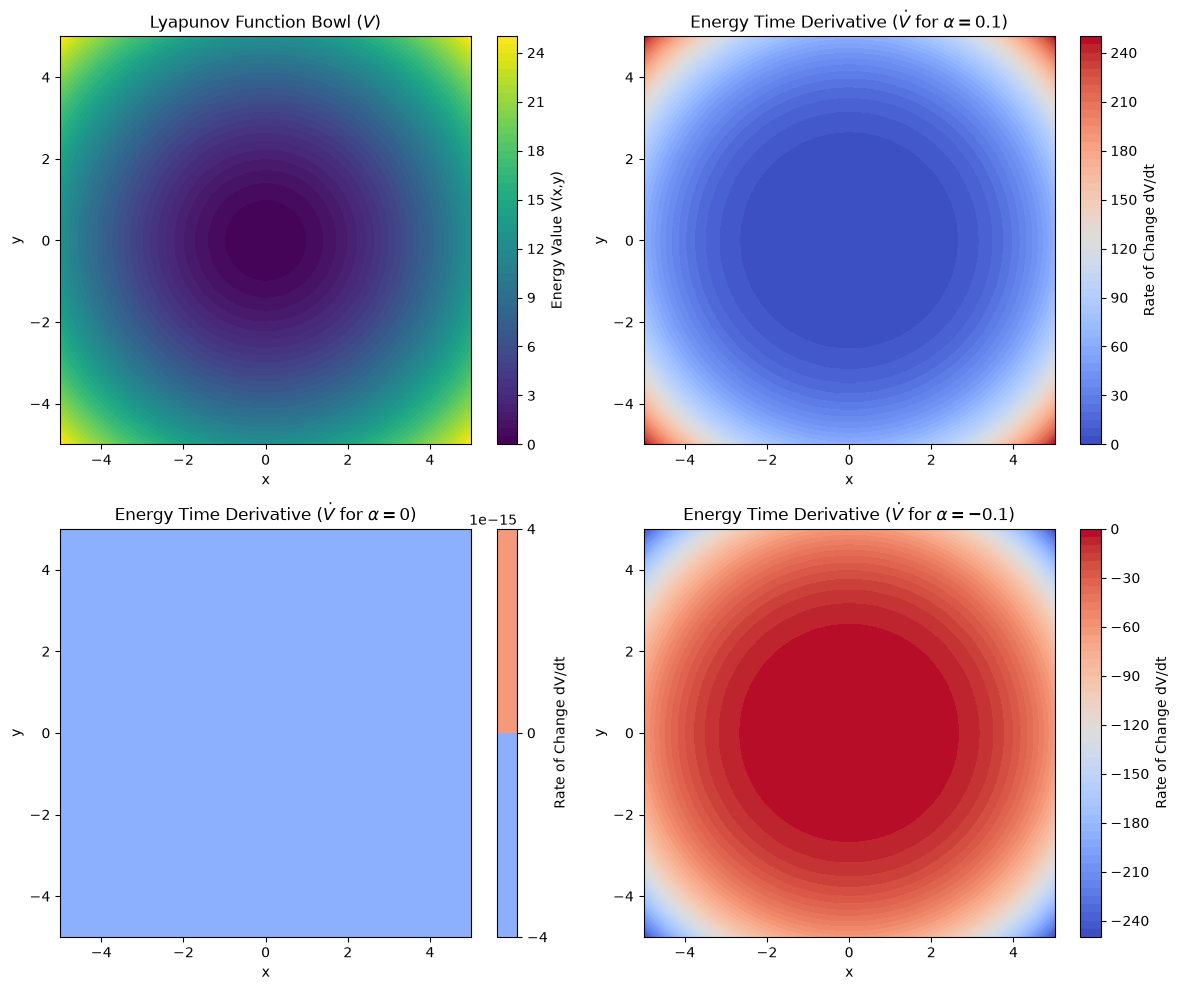

In [32]:
#Let's set up our functions

def lyapunov_V(X, Y):
    A = (X**2 + Y**2) / 2
    return A

def lyapunov_Vdot(X, Y, alpha):
    B = alpha * ((X**2 + Y**2)**2)
    return B

x_range = np.linspace(-5, 5, 500) 
y_range = np.linspace(-5, 5, 500)

X1, Y1 = np.meshgrid(x_range, y_range)

EV = lyapunov_V(X1,Y1)

alpha_pos = 0.1
alpha_zero = 0
alpha_neg = -0.1

EdV_pos= lyapunov_Vdot(X1,Y1,alpha_pos)
EdV_zero= lyapunov_Vdot(X1,Y1,alpha_zero)
EdV_neg= lyapunov_Vdot(X1,Y1,alpha_neg)

fig, axes = plt.subplots(2,2, figsize=(12,10))

contour_V = axes[0,0].contourf(X1, Y1, EV, levels=50, cmap ='viridis')
axes[0,0].set_title(r"Lyapunov Function Bowl ($V$)")
axes[0,0].set_xlabel("x")
axes[0,0].set_ylabel("y")
fig.colorbar(contour_V, ax=axes[0,0], label="Energy Value V(x,y)")

contour_Vdot = axes[0,1].contourf(X1, Y1, EdV_pos, levels=50, cmap='coolwarm')
axes[0,1].set_title(r"Energy Time Derivative ($\dot{V}$ for $\alpha = 0.1$)")
axes[0,1].set_xlabel("x")
axes[0,1].set_ylabel("y")
fig.colorbar(contour_Vdot, ax=axes[0,1], label="Rate of Change dV/dt")

contour_Vdot = axes[1,0].contourf(X1, Y1, EdV_zero, levels=50, cmap='coolwarm')
axes[1,0].set_title(r"Energy Time Derivative ($\dot{V}$ for $\alpha = 0$)")
axes[1,0].set_xlabel("x")
axes[1,0].set_ylabel("y")
fig.colorbar(contour_Vdot, ax=axes[1,0], label="Rate of Change dV/dt")

contour_Vdot = axes[1,1].contourf(X1, Y1, EdV_neg, levels=50, cmap='coolwarm')
axes[1,1].set_title(r"Energy Time Derivative ($\dot{V}$ for $\alpha = -0.1$)")
axes[1,1].set_xlabel("x")
axes[1,1].set_ylabel("y")
fig.colorbar(contour_Vdot, ax=axes[1,1], label="Rate of Change dV/dt")

plt.tight_layout()
plt.show()

### Takeaways
Now we can see how the Lyapunov mimics the phase plane. It's entirely dependent on the sign of alpha.

Why pick that V? 

It's globally positive definite, so it satisfies that criteria. At the origin, V=0, everywhere else V>0. It functions like an "energy bowl", so to speak.

The gradient is purely radial. Anywhere you pick, the vector points directly away from the origin, perfectly perpendicular to the circular contour lines. 

In our math, you can see how it cancels out the orbital rotation. So, this isolates alpha because it makes the rotational flow component equal to zero. 

#### Other Common Lyapunov functions

These are pretty interesting, so I thought I'd do some more digging.
##### Quadratic Forms
$$V(x) = x^{T}Px$$ where P is a symmetric, positive-definite matrix and $x^{T}$ is the transpose of x. In 2D, this looks like $$V(x,y)=ax^{2}+2bxy+cy^{2}$$ Ellipsoidal bowl, not a perfect circle.

This is chosen when it's a linear system $$\dot{x}=Ax$$ and linearised approximations of nonlinear systems. If a system stretches or shears trajectories more along one axis than another, you change the values in $P$ to stretch your energy bowl into an ellipse that perfectly aligns with that shearing behavior.

##### Total Energy/Hamiltonian Functions

V = Kinetic Energy + Potential Energy

$$V(x, \dot{x}) = \frac{1}{2}m\dot{x}^2 + \int_{0}^{x} F_{\text{restoring}}(s) \, ds$$

Used for mechanical, electrical, and aerospace systems. Works when the restoring force is nonlinear.

##### Logarithmic/Barrier Functions
These functions blow up to infinity as you approach a specific boundary.

Such as: $$V = x - \ln(x)$$ or $$V = -\sum \ln(b_i - a_ix)$$
Used in ecological models, like Lotka-Volterra predator-prey systems, and chemical kinetics, among others. The natural log acts as a wall, preventing the function from veering into impossible territory.

I'll need a lot of practice with these.



### Example 3
This utilises the forward Euler method $$x_{n+1}=x_{n}+\Delta t\dot{x_n}$$ and the harmonic oscillator.$$\ddot{x}+x=0$$ or $$\dot{x}=y, \dot{y}=-x$$ with $x(0)=x_{0}, y(0)=y_0$

Finding the exact solution is trivial and can be done by hand. 
$$
\begin{align*}
x(t) &= x_0 \cos(t) + y_0 \sin(t), \\
y(t) &= -x_0 \sin(t) + y_0 \cos(t),
\end{align*}
$$
Which can also be written as:
$$
\begin{pmatrix} x(t) \\ y(t) \end{pmatrix} = \begin{bmatrix} \cos(t) & \sin(t) \\ -\sin(t) & \cos(t) \end{bmatrix} \begin{pmatrix} x_0 \\ y_0 \end{pmatrix},
$$

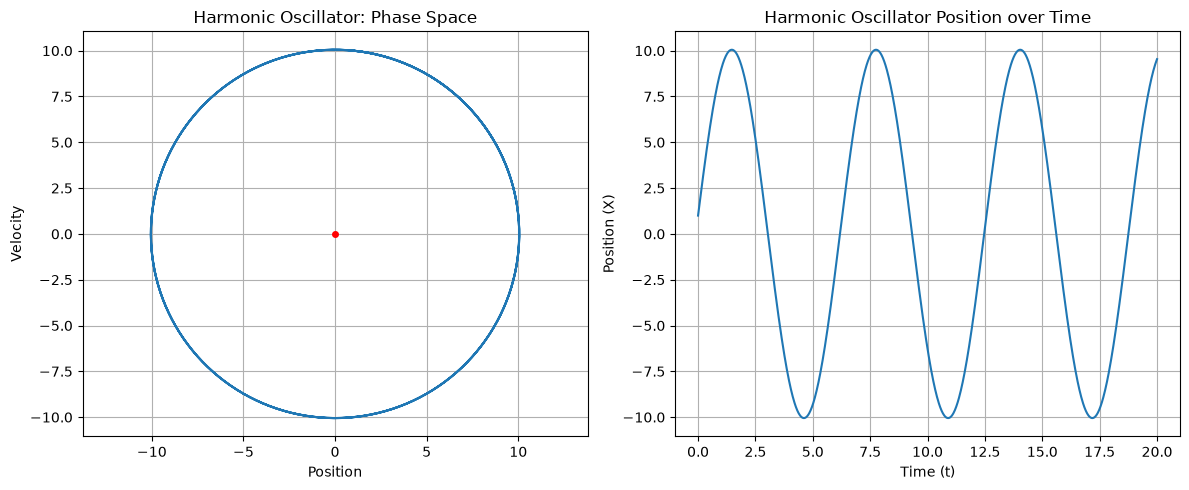

In [60]:
def Harmonic_oscillator(x0,y0, t):
    X = x0*np.cos(t) + y0*np.sin(t)
    Y = -x0*np.sin(t)+y0*np.cos(t)
    return [X,Y]
t=np.linspace(0, 20, 1000)

fig, axes = plt.subplots(1,2, figsize=(12,5))
X,Y = Harmonic_oscillator(1,10,t)
axes[0].plot(X,Y, label = "Phase Orbit")
axes[0].plot(0,0,'ro',markersize=4)
axes[0].set_title('Harmonic Oscillator: Phase Space')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Velocity')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(t,X, label="Position x(t)")
axes[1].set_title('Harmonic Oscillator Position over Time')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('Position (X)')
axes[1].grid(True)

plt.tight_layout()
plt.show()



This is how the Harmonic Oscillator behaves. It conserves area ($det[A] =cos^{2}(t)+sin^{2}(t)=1$) Let's compare it to a Forward Euler approximation.

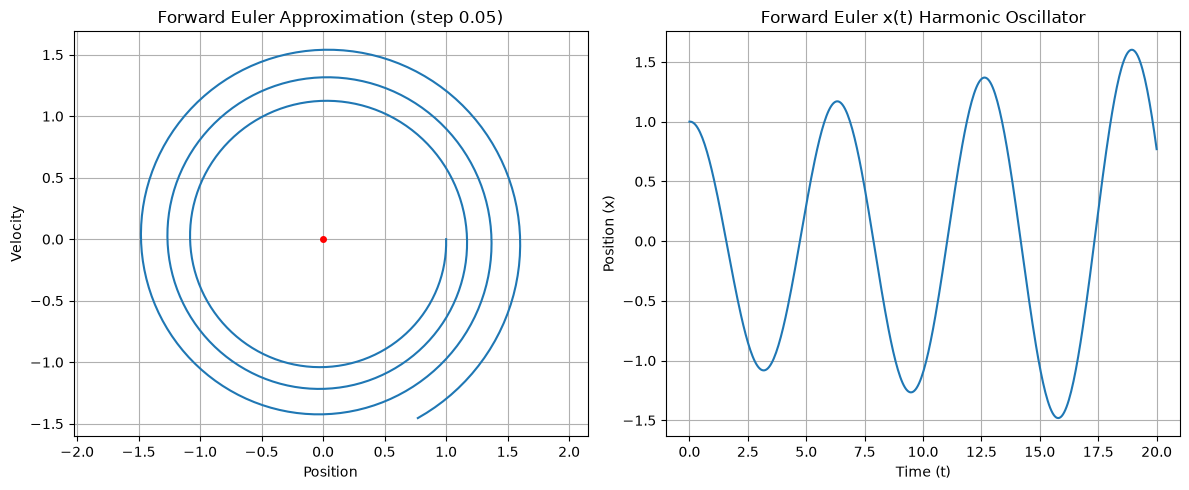

In [59]:
dt=0.05 #small blocks of time
t_max=20 #Simulate it over 20 seconds
N=int(t_max/dt) #The amount of calculations - this needs to be an integer for the arrays later

t=np.linspace(0,t_max,N) #an array of 400 evenly spaced numbers from 0 to 20
X=np.zeros(N)
Y=np.zeros(N)
#overwriting zeroes is more efficient than appending an array
X[0]=1 #starting position
Y[0]=0 #starting velocity
for i in range(N-1): # N-1 because our loop runs to i+1
    dx_dt=Y[i] #velocity
    dy_dt=-X[i] #acceleration
    X[i+1]=X[i]+dx_dt*dt #Takes position, checks slope, adds that slope proportionate to step
    Y[i+1]=Y[i]+dy_dt*dt #Same as above, for the y axis.

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(X,Y)
axes[0].grid(True)
axes[0].plot(0, 0, 'ro', markersize=4, label="Stable Centre")
axes[0].set_title('Forward Euler Approximation (step 0.05)')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Velocity')
axes[0].axis('equal')

axes[1].plot(t,X)
axes[1].grid(True)
axes[1].set_title('Forward Euler x(t) Harmonic Oscillator')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('Position (x)')

plt.tight_layout()
plt.show()


Small note: Euler's method is essentially a first order Taylor series.

### Example 4
This utilises the backward Euler method. It's pretty similar to the forward: $$x_{n+1} = x_{n} + \Delta t \dot x_{n+1}$$

We're given the linear ODE $\dot{x} = ax$ with $x(0)=x_0$

Let's let $a=1$ and $x_{0}=1$ arbitrarily and see where the forward and backward method diverge.

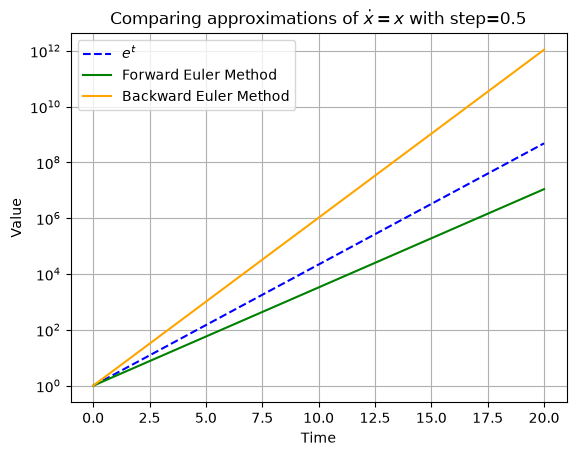

In [70]:
dt = 0.5
t_max = 20
N = int(t_max/dt)+1

t= np.linspace(0,t_max,N)
X1=np.zeros(N)
X1[0]=1
X2=np.zeros(N)
X2[0]=1
for i in range(N-1):
    dx_dt=X1[i]
    X1[i+1]=X1[i]+dx_dt*dt 
    X2[i+1]=X2[i]/(1-dt)
    
plt.plot(t,np.exp(t), label="$e^{t}$", color="blue", linestyle="--")
plt.plot(t,X1,label="Forward Euler Method", color="green")
plt.plot(t,X2,label="Backward Euler Method",color="orange")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.yscale("log")
plt.legend()
plt.title(r"Comparing approximations of $\dot{x}=x$ with step=0.5")
plt.show()
    
    

So, Forward undershoots it, and Backward overshoots it.